Imports and Paths

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [7]:
# Paths
splits = {
    "train_labeled_flooded": r"C:\Users\rjunt\Downloads\Train-20260408T142735Z-3-001\Train\Labeled\Flooded\image",
    "train_labeled_non_flooded": r"C:\Users\rjunt\Downloads\Train-20260406T143030Z-3-003\Train\Labeled\Non-Flooded\image",
    "validation": r"C:\Users\rjunt\Downloads\Validation-20260406T142917Z-3-002\Validation\image",
    "test": r"C:\Users\rjunt\Downloads\Test-20260406T142909Z-3-002\Test\image"
}

mask_path = r"C:\Users\rjunt\Downloads\Train-20260408T142735Z-3-001\Train\Labeled\Flooded\mask"

EDA Graph #1: Bar Chart of Images per Dataset Split

In [8]:
# Count number of images in each split
image_counts = {}

for split, path in splits.items():
    if os.path.exists(path):
        image_counts[split] = len([
            f for f in os.listdir(path)
            if f.lower().endswith((".jpg", ".png"))
        ])
    else:
        print(f"Missing path: {path}")
        image_counts[split] = 0

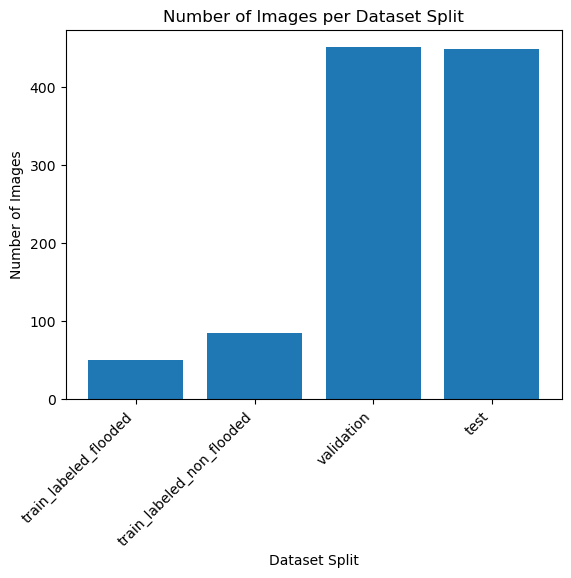

In [9]:
# Plot bar chart
plt.figure()
plt.bar(image_counts.keys(), image_counts.values())
plt.xticks(rotation=45, ha='right')
plt.title("Number of Images per Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.show()


EDA Graph #2: Segmentation Class Pixel Distirbution

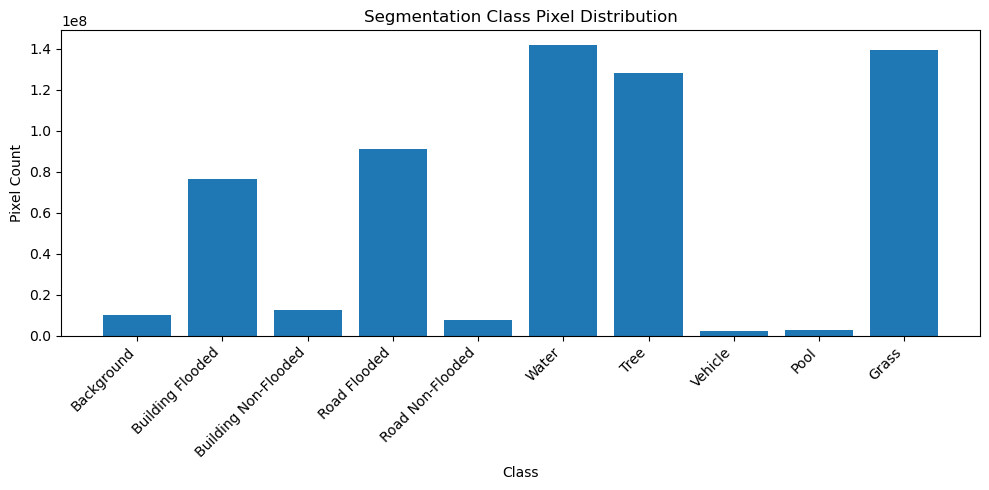

In [10]:
# All listed class names and their corresponding pixel values in the segmentation masks
class_names = {
    0: "Background",
    1: "Building Flooded",
    2: "Building Non-Flooded",
    3: "Road Flooded",
    4: "Road Non-Flooded",
    5: "Water",
    6: "Tree",
    7: "Vehicle",
    8: "Pool",
    9: "Grass"
}

class_counts = {k: 0 for k in class_names.keys()}
mask_files = [f for f in os.listdir(mask_path) if f.lower().endswith(".png")]

# count pixels for each class across all masks
for f in mask_files[:200]:
    mask = np.array(Image.open(os.path.join(mask_path, f)))
    unique, counts = np.unique(mask, return_counts=True)
    for u, c in zip(unique, counts):
        if u in class_counts:
            class_counts[u] += c

# Plot chart
plt.figure(figsize=(10,5))
plt.bar([class_names[k] for k in class_counts.keys()], class_counts.values())
plt.title("Segmentation Class Pixel Distribution")
plt.xlabel("Class")
plt.ylabel("Pixel Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

EDA Graph #3: Flooded vs. Non-Flooded Pixel Counts in Masks

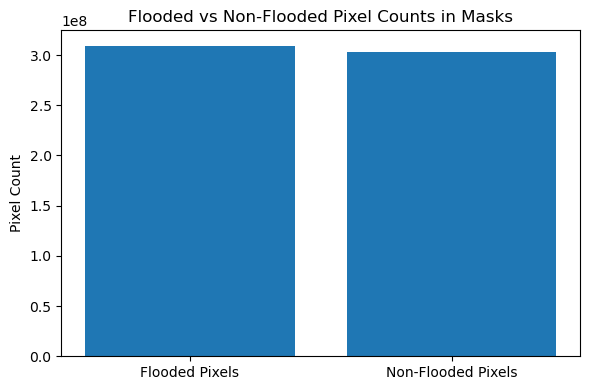

In [11]:
flood_classes = [1, 3, 5]  # Combined flood classes: Flooded, Road Flooded, Water

flood_pixels = 0
non_flood_pixels = 0

# Count number of flooded pixesls vs. non-flooded pixels across all masks
for f in mask_files[:200]:  # limit to speed
    mask = np.array(Image.open(os.path.join(mask_path, f)))
    flood_mask = np.isin(mask, flood_classes)
    flood_pixels += np.sum(flood_mask)
    non_flood_pixels += np.sum(~flood_mask)

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(["Flooded Pixels", "Non-Flooded Pixels"], [flood_pixels, non_flood_pixels])
plt.title("Flooded vs Non-Flooded Pixel Counts in Masks")
plt.ylabel("Pixel Count")
plt.tight_layout()
plt.show()